# Line vs Rectangle (Paper Outputs Only)

This notebook keeps the code required to generate:

- `line_rect_Data.pdf` (panel (i) Figure 2)
- `line_rec_eigenvecs.pdf` (panel (iii) Figure 2)
- `line_rec_differential.pdf` (panel (iv) Figure 2)
- `Rec_vsLine_summary_table.tex` (Table 2)
- `graph_modality_A_B_line.pdf` (panel (ii) Figure 2)


In [10]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eig

# Ensure imports work whether Jupyter runs from project root or notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from functions import diffusion_map, LG_sym, calc_differential_vec

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

import networkx as nx
from sklearn.neighbors import NearestNeighbors


In [2]:
# Synthetic line-vs-rectangle data
N = 2000
L = 4
W = 2
RNG_SEED = 42

np.random.seed(RNG_SEED)

w = np.random.uniform(0, W, N)
w = w[np.argsort(w)]
l = np.random.uniform(0, L, N)

X1 = l[:, np.newaxis]
X2 = np.column_stack((l, w))


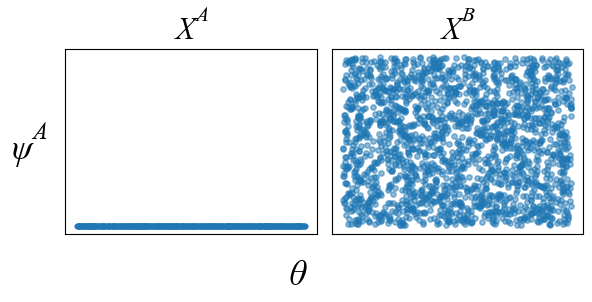

In [3]:
# Output 1: line_rect_Data.pdf
fig, ax = plt.subplots(1, 2, figsize=(6, 3), layout='tight', sharex=True, sharey=True)

ax[0].scatter(X2[:, 0], np.zeros(N), s=10, alpha=0.3)
ax[0].set_title(r'$X^A$', fontsize=22)

ax[1].scatter(X2[:, 0], X2[:, 1], s=15, alpha=0.5)
ax[1].set_title(r'$X^B$', fontsize=22)

fig.supxlabel(r'$\theta$', fontsize=25)
fig.supylabel(r'$\psi^A$', fontsize=25, rotation=0)

for axi in fig.get_axes():
    axi.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

plt.tight_layout()
plt.savefig('line_rect_Data.pdf', bbox_inches='tight')
plt.show()


In [8]:
def knn_binary_graph(X, k):
    X = np.asarray(X)
    n = X.shape[0]
    nn = NearestNeighbors(n_neighbors=k + 1, algorithm='auto')
    nn.fit(X)
    idx = nn.kneighbors(return_distance=False)

    A = np.zeros((n, n), dtype=np.uint8)
    for i in range(n):
        nbrs = idx[i, 1:]  # drop self
        A[i, nbrs] = 1

    # Make graph undirected
    A = ((A | A.T) > 0).astype(np.uint8)
    return A


def graph_with_auto_layout(A, layout='kamada_kawai', seed=0):
    A = np.asarray(A)
    G = nx.from_numpy_array(A)

    if layout == 'spring':
        pos = nx.spring_layout(G, seed=seed)
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    elif layout == 'spectral':
        pos = nx.spectral_layout(G)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    else:
        raise ValueError('Unknown layout type')

    return G, pos


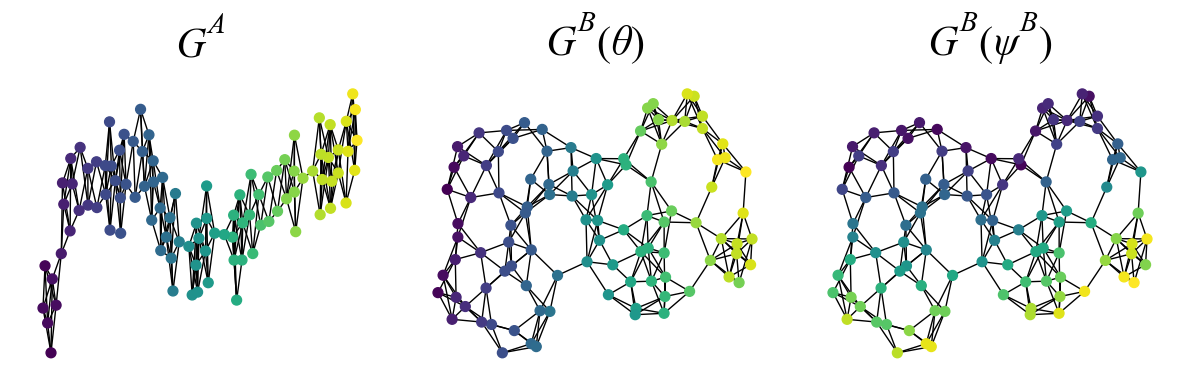

In [11]:
# Output 5: graph_modality_A_B_line.pdf
n_graph = 100
L_graph = 4
W_graph = 2

np.random.seed(42)
w_graph = np.random.uniform(0, W_graph, n_graph)
w_graph = w_graph[np.argsort(w_graph)]
l_graph = np.random.uniform(0, L_graph, n_graph)

XA = l_graph[:, np.newaxis]
XB = np.column_stack((l_graph, w_graph))

A_graph = knn_binary_graph(XA, k=4)
G_A, pos_A = graph_with_auto_layout(A_graph, layout='kamada_kawai')

B_graph = knn_binary_graph(XB, k=4)
G_B, pos_B = graph_with_auto_layout(B_graph, layout='kamada_kawai')

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

nx.draw(
    G_A,
    pos_A,
    ax=ax[0],
    node_size=50,
    node_color=XA[:, 0],
    with_labels=False,
)
ax[0].set_title(r'$G^A$', fontsize=30)

nx.draw(
    G_B,
    pos_B,
    ax=ax[1],
    node_size=50,
    node_color=XB[:, 0],
    with_labels=False,
)
ax[1].set_title(r'$G^B(\theta)$', fontsize=30)

nx.draw(
    G_B,
    pos_B,
    ax=ax[2],
    node_size=50,
    node_color=XB[:, 1],
    with_labels=False,
)
ax[2].set_title(r'$G^B(\psi^B)$', fontsize=30)

for a in ax:
    a.set_axis_off()

plt.tight_layout()
plt.savefig('graph_modality_A_B_line.pdf')
plt.show()


In [4]:
# Build diffusion operators and differential vectors
_, _, K1 = diffusion_map(X1, adaptive=1800)
_, _, K2 = diffusion_map(X2, adaptive=1800)

L1, d1, v1 = LG_sym(K1)
L2, d2, v2 = LG_sym(K2)

s1, u1 = calc_differential_vec(L2, v1, k=5)


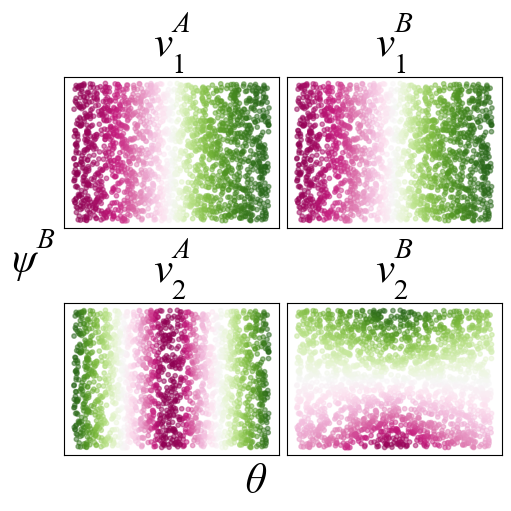

In [5]:
# Output 2: line_rec_eigenvecs.pdf
fig, ax = plt.subplots(2, 2, figsize=(5, 5), layout='constrained', sharex=True, sharey=True)

for i in range(2):
    ax[i, 0].scatter(X2[:, 0], X2[:, 1], c=v1[:, i + 1], cmap='PiYG', alpha=0.5, s=10)
    ax[i, 1].scatter(X2[:, 0], X2[:, 1], c=v2[:, i + 1], cmap='PiYG', alpha=0.5, s=10)
    ax[i, 0].set_title(r'$v_{}^A$'.format(i + 1), fontsize=30, pad=15)
    ax[i, 1].set_title(r'$v_{}^B$'.format(i + 1), fontsize=30, pad=15)

for axi in fig.get_axes():
    axi.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

fig.supxlabel(r'$\theta$', fontsize=30)
fig.supylabel(r'$\psi^B$', fontsize=30, rotation=0)
plt.savefig('line_rec_eigenvecs.pdf', bbox_inches='tight')
plt.show()


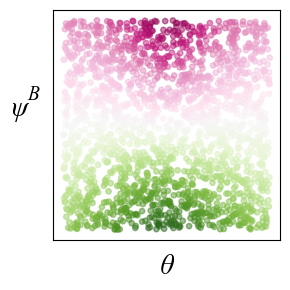

In [6]:
# Output 3: line_rec_differential.pdf
plt.figure(figsize=(3, 3))
plt.scatter(X2[:, 0], X2[:, 1], c=u1[:, 0], cmap='PiYG', alpha=0.5, s=15)

plt.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
plt.xlabel(r'$\theta$', fontsize=20, labelpad=10)
plt.ylabel(r'$\psi^B$', fontsize=20, rotation=0, labelpad=20)

plt.tight_layout()
plt.savefig('line_rec_differential.pdf', bbox_inches='tight')
plt.show()


## Summary Table Simulation

In [ ]:
def rectangle_corr(L, W, N, k=5):
    w = np.random.uniform(0, W, N)
    w = w[np.argsort(w)]
    l = np.random.uniform(0, L, N)

    X1 = l[:, np.newaxis]
    X2 = np.column_stack((l, w))

    v_th = np.cos(np.pi * w / W)
    v_th = v_th / np.linalg.norm(v_th)

    P1, Q1, K1 = diffusion_map(X1, adaptive=int(0.6 * N))
    P2, Q2, K2 = diffusion_map(X2, adaptive=int(0.6 * N))

    L1, _, v1 = LG_sym(K1)
    L2, _, v2 = LG_sym(K2)

    _, u1 = calc_differential_vec(L2, v1, k)
    corr_dv = np.corrcoef(v_th, u1[:, 0])[0, 1]

    S = P2 @ Q1 + P1 @ Q2
    D = P2 @ Q1 - P1 @ Q2

    es_vals, _ = eig(S)
    _ = np.argsort(es_vals)[::-1]  # kept for parity with prior workflow

    ea_vals, va = eig(D)
    va = va[:, np.argsort(np.imag(ea_vals))[::-1]]
    va_real = np.real(va)
    va_imag = np.imag(va)

    corr_sh_real = np.corrcoef(va_real[:, 0], v_th)[0, 1]
    corr_sh_imag = np.corrcoef(va_imag[:, 0], v_th)[0, 1]

    g1 = np.diag(np.sum(K1, axis=0)) - K1
    g2 = np.diag(np.sum(K2, axis=0)) - K2

    m1 = g1 + 1e-6 * np.eye(g1.shape[0])
    m2 = g2 + 1e-6 * np.eye(g2.shape[0])

    fk1 = np.linalg.inv(m1 + m2) @ m1
    fk_values_1, eig_vec_fk_1 = eig(fk1)
    eig_vec_fk_1 = eig_vec_fk_1[:, np.argsort(fk_values_1)[::-1]]
    corr_fk = np.corrcoef(v_th, eig_vec_fk_1[:, 0])[0, 1]

    return corr_dv, corr_fk, corr_sh_real, corr_sh_imag


In [ ]:
# Output 4: Rec_vsLine_summary_table.tex
B = 500
N = 2000
W = 2
L = 4

acc_rectangle = np.zeros((B, 4))
for i in range(B):
    acc_rectangle[i, :] = rectangle_corr(L, W, N, k=5)

columns = ['DV', 'FKT', 'Shnitzer et al. (real)', 'Shnitzer et al. (imag)']
df = pd.DataFrame(np.abs(acc_rectangle), columns=columns)

# Keep original paper-summary slicing behavior for compatibility
SUMMARY_ROWS = 342
display_cols = ['DV', 'Shnitzer et al. (real)', 'Shnitzer et al. (imag)', 'FKT']
display_names = ['DiLVE', 'Shnitzer et al. (real)', 'Shnitzer et al. (imag)', 'FK']

summary_values = []
for col in display_cols:
    mean_val = df.iloc[:SUMMARY_ROWS][col].mean()
    sd_val = df.iloc[:SUMMARY_ROWS][col].std()
    summary_values.append(f'{mean_val:.3f} ({sd_val:.3f})')

summary_df = pd.DataFrame([summary_values], columns=display_names, index=['Mean (SD)'])
display(summary_df)
summary_df.to_latex('Rec_vsLine_summary_table.tex', index=True, float_format='%.3f')
